In [1]:
### Parte A:

In [2]:
#Importamos paquetes
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm 

from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
# Del tp anterior, importamos la base construida para lo pedido en ella.

In [4]:
os.chdir(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\TP3")

In [5]:
ocupados = pd.read_csv("ocupados.csv")

In [6]:
ocupados

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH14,CH15_COD,...,PP07H,informal,EMPLEO,edad2,CH12,CH13,educ,ingreso_total_familiar,horastrab,ix_tot
0,1.0,39.0,1.0,4.0,4.0,1.0,0.0,1.391111e+05,NaN,NaN,...,0.0,0,2.0,1521.0,4.0,1.0,NaN,1252000.0,NaN,9
1,1.0,35.0,5.0,1.0,6.0,1.0,0.0,2.500000e+06,NaN,NaN,...,2.0,1,2.0,1225.0,7.0,1.0,17.0,2500000.0,48.0,1
2,2.0,46.0,3.0,1.0,6.0,1.0,0.0,1.133333e+06,NaN,NaN,...,1.0,0,1.0,2116.0,7.0,1.0,17.0,3400000.0,45.0,3
3,1.0,38.0,2.0,1.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,1.0,0,1.0,1444.0,4.0,2.0,NaN,0.0,44.0,10
4,2.0,42.0,2.0,4.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,2.0,1,2.0,1764.0,4.0,2.0,NaN,0.0,NaN,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3877,1.0,53.0,5.0,1.0,2.0,1.0,0.0,3.800000e+02,NaN,NaN,...,1.0,0,NaN,2809.0,2.0,1.0,6.0,1081905.6,NaN,3
3878,1.0,52.0,2.0,4.0,2.0,1.0,0.0,1.533333e+02,NaN,NaN,...,2.0,1,NaN,2704.0,2.0,1.0,6.0,436558.4,114.0,3
3879,2.0,38.0,3.0,12.0,6.0,1.0,0.0,2.500000e+02,NaN,NaN,...,1.0,0,NaN,1444.0,6.0,1.0,15.0,474520.0,49.0,2
3880,1.0,28.0,2.0,4.0,2.0,1.0,0.0,1.250000e+02,NaN,NaN,...,0.0,0,NaN,784.0,2.0,1.0,6.0,711780.0,4.0,6


In [7]:
# Dado a que evidentemente la variable educ está teniendo problemas por la diferencia de escalas entre las bases
# del tp2, vamos a construir de vuelta esta variable cosa que no tenga tantos missing values

In [8]:
# Reconstruir educ en la base ocupados
ocupados['educ'] = np.nan

# Jardín / preescolar
ocupados.loc[ocupados['CH12'] == 1, 'educ'] = 0

# Primario
ocupados.loc[(ocupados['CH12'] == 2) & (ocupados['CH13'] == 2), 'educ'] = ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 2) & (ocupados['CH13'] == 1), 'educ'] = 6

# EGB
ocupados.loc[(ocupados['CH12'] == 3) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,9)), 'educ'] = ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 3) & (ocupados['CH13'] == 1), 'educ'] = 9

# Secundario
ocupados.loc[(ocupados['CH12'] == 4) & (ocupados['CH13'] == 2), 'educ'] = 6 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 4) & (ocupados['CH13'] == 1), 'educ'] = 12

# Polimodal
ocupados.loc[(ocupados['CH12'] == 5) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,3)), 'educ'] = 9 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 5) & (ocupados['CH13'] == 1), 'educ'] = 12

# Terciario
ocupados.loc[(ocupados['CH12'] == 6) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,9)), 'educ'] = 12 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 6) & (ocupados['CH13'] == 1), 'educ'] = 15

# Universitario
ocupados.loc[(ocupados['CH12'] == 7) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,9)), 'educ'] = 12 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 7) & (ocupados['CH13'] == 1), 'educ'] = 17

# Posgrado
ocupados.loc[(ocupados['CH12'] == 8) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,9)), 'educ'] = 17 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 8) & (ocupados['CH13'] == 1), 'educ'] = 19

# Educación especial → missing
ocupados.loc[ocupados['CH12'] == 9, 'educ'] = np.nan

# Verificar
print(ocupados.groupby('AÑO')['educ'].describe())

       count       mean        std  min  25%   50%   75%    max
AÑO                                                            
2005  1817.0  10.334067   4.697936  0.0  6.0  11.0  13.0  105.0
2025  2036.0  13.069253  10.589950  0.0  9.0  12.0  15.0  105.0


In [9]:
# Limpiar outliers de educ (99 y 105 son NS/NR en la EPH)
ocupados.loc[ocupados['educ'] >= 25, 'educ'] = np.nan

In [10]:
### 1)

In [11]:
### 1)

In [12]:
ocupados_2005 = ocupados[ocupados['AÑO'] == 2005]
ocupados_2025 = ocupados[ocupados['AÑO'] == 2025]

In [13]:
### 2)

In [14]:
print("Tipo de dato:", ocupados['educ'].dtype)
print("\nNaN por año:")
print(ocupados.groupby('AÑO')['educ'].apply(lambda x: x.isna().sum()))
print("\nValores únicos (primeros 10):", ocupados['educ'].unique()[:10])
print("\nDescriptiva por año:")
print(ocupados.groupby('AÑO')['educ'].describe())

Tipo de dato: float64

NaN por año:
AÑO
2005    12
2025    42
Name: educ, dtype: int64

Valores únicos (primeros 10): [12. 17. nan  9. 15.  8.  7.  6. 10.  3.]

Descriptiva por año:
       count       mean       std  min  25%   50%   75%   max
AÑO                                                          
2005  1816.0  10.281938  4.140351  0.0  6.0  11.0  13.0  22.0
2025  2012.0  11.987575  3.756029  0.0  9.0  12.0  15.0  20.0


In [15]:
# Variables predictoras
variables_x = [
    'CH06',
    'edad2',
    'educ',
    'ingreso_total_familiar',
    'horastrab',
    'ix_tot'
]

# Lista para resultados
resultados = []

for var in variables_x:
    x2005 = ocupados_2005[var].dropna()
    x2025 = ocupados_2025[var].dropna()

    media_2005 = x2005.mean()
    media_2025 = x2025.mean()
    diferencia = media_2025 - media_2005

    t_stat, p_value = ttest_ind(x2025, x2005, equal_var=False)

    resultados.append({
        'Variable': var,
        'Media 2005': media_2005,
        'Media 2025': media_2025,
        'Diferencia': diferencia,
        'p-value': p_value
    })

tabla_medias = pd.DataFrame(resultados)
tabla_medias

,Variable,Media 2005,Media 2025,Diferencia,p-value
0,CH06,3.935722e+01,4.112123e+01,1.764006,4.196016e-05
1,edad2,1.727737e+03,1.869914e+03,142.176956,1.396393e-04
2,educ,1.028194e+01,1.198757e+01,1.705636,1.908960e-39
3,ingreso_total_familiar,1.416588e+06,1.297905e+06,-118682.845353,5.003258e-03
4,horastrab,4.363268e+01,3.796122e+01,-5.671460,1.369044e-10
5,ix_tot,4.395514e+00,3.675268e+00,-0.720246,1.915038e-32


In [16]:
### 3)

In [17]:
# Hagamos primero para la base de 2025

In [18]:
# La variable y va a estar definida por la variable que creamos en el tp anterior llamada "informal"
# El resto forma parte de las variables dependientes, es decir edad2, educ, ingreso_total_familiar, horastrab y ix_tot
# Construyamos primero eso entonces

In [19]:
# Guardemos primero las variables X relevantes solo para 2025

var_x = [
    'edad2',
    'educ',
    'ingreso_total_familiar',
    'horastrab',
    'ix_tot'
]

# Filtrar solamente las observaciones de 2025
ocupados_2025 = ocupados[ocupados['AÑO'] == 2025].copy()

# Crear la matriz X con solo esas variables
X_2025 = ocupados_2025[var_x].copy()

In [20]:
# Lo mismo vamos a hacer para 2005

# Filtrar solamente las observaciones de 2025
ocupados_2005 = ocupados[ocupados['AÑO'] == 2005].copy()

# Crear la matriz X con solo esas variables
X_2005 = ocupados_2005[var_x].copy()

In [21]:
X_2025

,edad2,educ,ingreso_total_familiar,horastrab,ix_tot
0,1521.0,12.0,1252000.0,NaN,9
1,1225.0,17.0,2500000.0,48.0,1
2,2116.0,17.0,3400000.0,45.0,3
3,1444.0,NaN,0.0,44.0,10
4,1764.0,NaN,0.0,NaN,10
...,...,...,...,...,...
2049,676.0,12.0,1745000.0,20.0,2
2050,4096.0,6.0,611306.0,35.0,3
2051,2809.0,12.0,1850000.0,40.0,2
2052,3136.0,15.0,1850000.0,NaN,2


In [22]:
X_2005

,edad2,educ,ingreso_total_familiar,horastrab,ix_tot
2054,2601.0,12.0,2372600.0,60.0,4
2055,529.0,17.0,2372600.0,NaN,4
2056,1225.0,6.0,332164.0,46.0,4
2057,1225.0,6.0,332164.0,NaN,4
2058,1764.0,6.0,1613368.0,57.0,7
...,...,...,...,...,...
3877,2809.0,6.0,1081905.6,NaN,3
3878,2704.0,6.0,436558.4,114.0,3
3879,1444.0,15.0,474520.0,49.0,2
3880,784.0,6.0,711780.0,4.0,6


In [23]:
# Ahora, guardemos también por separado la variable dependiente y:

y_2025 = ocupados_2025['informal'].copy()
y_2005= ocupados_2005['informal'].copy()

In [24]:
print(X_2025.shape)
print(y_2025.shape)

print(X_2005.shape)
print(y_2005.shape)

(2054, 5)
(2054,)
(1828, 5)
(1828,)


In [25]:
# Con esto, deberíamos poder divir las muestras entre train y test con la función dada

In [26]:
X2025_train, X2025_test, y2025_train, y2025_test = train_test_split(X_2025, y_2025, test_size=0.30, random_state=444)

In [27]:
X2005_train, X2005_test, y2005_train, y2005_test = train_test_split(X_2005, y_2005, test_size=0.30, random_state=444)

In [28]:
# Me estaría faltando agregar la constante nada más 

In [29]:
X2025_train['constante'] = 1

X2025_test['constante'] = 1

In [30]:
X2005_train['constante'] = 1

X2005_test['constante'] = 1

In [31]:
### Parte b

In [32]:
### 1) 

In [33]:
# Realicemos la regresión logistica mediante el uso de X2025_train y X2005_train

In [34]:
# Verificamos si existen nonvalues dentro de las bases de train

In [35]:
print(X2025_train.shape)
print(y2025_train.shape)
print(X2025_train.isna().sum().sum())
print(y2025_train.isna().sum())

(1437, 6)
(1437,)
799
0


In [36]:
X2025_train.isna().sum()

edad2                       0
educ                       29
ingreso_total_familiar      0
horastrab                 770
ix_tot                      0
constante                   0
dtype: int64

In [37]:
X2025_train.dtypes

edad2                     float64
educ                      float64
ingreso_total_familiar    float64
horastrab                 float64
ix_tot                      int64
constante                   int64
dtype: object

In [38]:
y2025_train.isna().sum()

np.int64(0)

In [39]:
# Eliminemos los missing values porque sino no podríamos trabajar

# Unir X e y
train_2025 = pd.concat([X2025_train, y2025_train], axis=1)

# Eliminar filas con NaN
train_2025 = train_2025.dropna()

# Separar nuevamente
X2025_train = train_2025.drop(columns=['informal'])
y2025_train = train_2025['informal']

In [40]:
# Verifiquemos de vuelta si se sacaron correctamente los missing values

print(X2025_train.shape)
print(y2025_train.shape)
print(X2025_train.isna().sum().sum())
print(y2025_train.isna().sum())

(652, 6)
(652,)
0
0


In [41]:
# Ahora si, hagamos la regresión logistica:

log_reg = LogisticRegression(penalty=None, max_iter=1000)
log_reg.fit(X2025_train, y2025_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [42]:
print(log_reg.coef_)
print(log_reg.intercept_)

[[-3.51974083e-04 -9.51401539e-02 -2.46438557e-07 -1.77652004e-02
   3.56624201e-02  8.25915339e-01]]
[0.82591534]


In [43]:
# Calculamos los odds ratio
odds_ratio = np.exp(log_reg.coef_)
print(odds_ratio)

[[0.99964809 0.90924549 0.99999975 0.98239167 1.03630595 2.28397042]]


In [44]:
# Hagamos el mismo proceso para 2005

In [45]:
# Eliminemos los missing values porque sino no podríamos trabajar

# Unir X e y
train_2005 = pd.concat([X2005_train, y2005_train], axis=1)

# Eliminar filas con NaN
train_2005 = train_2005.dropna()

# Separar nuevamente
X2005_train = train_2005.drop(columns=['informal'])
y2005_train = train_2005['informal']

In [46]:
# Ahora si, hagamos la regresión logistica:

log_reg2 = LogisticRegression(penalty=None, max_iter=1000)
log_reg2.fit(X2005_train, y2005_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
print(log_reg2.coef_)
print(log_reg2.intercept_)

[[ 9.76032678e-05 -1.60806208e-02 -1.12451613e-06 -1.08125889e-02
   1.31851119e-01  2.18437103e-02]]
[0.02184371]


In [48]:
# Calculamos los odds ratio
odds_ratio2 = np.exp(log_reg2.coef_)
print(odds_ratio2)

[[1.00009761 0.98404798 0.99999888 0.98924566 1.14093844 1.02208403]]


In [49]:
# Construyamos la tabla pedida de la misma forma que la presentada en clases

In [50]:
# Variables reales usadas en cada regresión
variables_2025 = list(X_2025.columns)
variables_2005 = list(X_2005.columns)

# Coeficientes
coef_2025 = log_reg.coef_[0]
coef_2005 = log_reg2.coef_[0]

# Interceptos
intercepto_2025 = log_reg.intercept_[0]
intercepto_2005 = log_reg2.intercept_[0]

# Odds ratios
odds_2025 = np.exp(coef_2025)
odds_2005 = np.exp(coef_2005)

odds_intercepto_2025 = np.exp(intercepto_2025)
odds_intercepto_2005 = np.exp(intercepto_2005)

# Tabla
filas = []

# Intercepto / constante
filas.append({
    "Predictor": "Constante",
    "Coeficiente 2025": intercepto_2025,
    "Odds ratio 2025": odds_intercepto_2025,
    "Coeficiente 2005": intercepto_2005,
    "Odds ratio 2005": odds_intercepto_2005
})

# Variables de X
for i, var in enumerate(variables_2025):
    filas.append({
        "Predictor": var,
        "Coeficiente 2025": coef_2025[i],
        "Odds ratio 2025": odds_2025[i],
        "Coeficiente 2005": coef_2005[i],
        "Odds ratio 2005": odds_2005[i]
    })

tabla_regresion = pd.DataFrame(filas)

tabla_regresion = tabla_regresion.round(4)

display(tabla_regresion)

,Predictor,Coeficiente 2025,Odds ratio 2025,Coeficiente 2005,Odds ratio 2005
0,Constante,0.8259,2.2840,0.0218,1.0221
1,edad2,-0.0004,0.9996,0.0001,1.0001
2,educ,-0.0951,0.9092,-0.0161,0.9840
3,ingreso_total_familiar,-0.0000,1.0000,-0.0000,1.0000
4,horastrab,-0.0178,0.9824,-0.0108,0.9892
5,ix_tot,0.0357,1.0363,0.1319,1.1409


In [51]:
### 2)

In [52]:
# Realizemos el gráfico pedido. Para el eje horizontal utilizemos educ

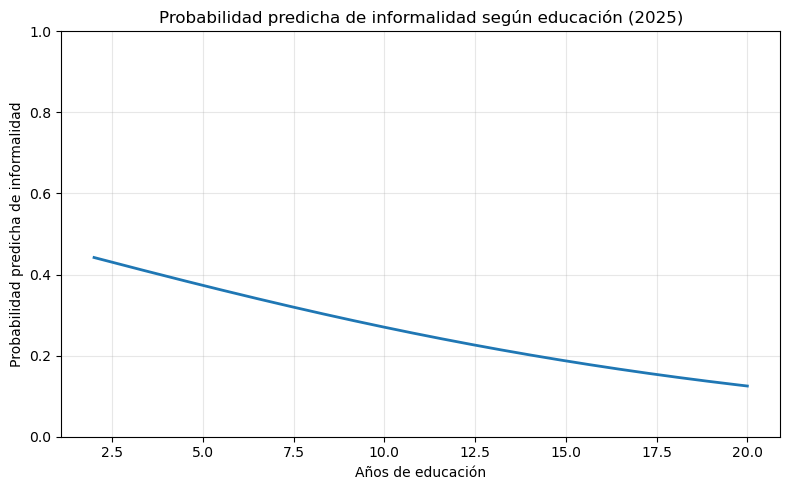

In [56]:
# Elegimos 'educ' como variable a ilustrar (podés cambiarla por CH06, horastrab, etc.)
var = 'educ'

# Base limpia para el gráfico
df_graf = X2025_train.copy()
df_graf = df_graf[df_graf['educ'].between(0, 25)]

# Valores del eje X
x_vals = np.linspace(df_graf[var].min(), df_graf[var].max(), 200)

# Promedio de las variables
x_mean = X2025_train.mean()

# Crear grilla
X_grid = pd.DataFrame(
    np.tile(x_mean.values, (len(x_vals), 1)),
    columns=X2025_train.columns
)

# Reemplazar la variable de interés
X_grid[var] = x_vals

# Probabilidades predichas
p_hat = log_reg.predict_proba(X_grid)[:, 1]

# Gráfico
plt.figure(figsize=(8, 5))
plt.plot(x_vals, p_hat, linewidth=2)

plt.xlabel('Años de educación')
plt.ylabel('Probabilidad predicha de informalidad')
plt.title('Probabilidad predicha de informalidad según educación (2025)')

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()